<a href="https://colab.research.google.com/github/aaa020109-star/causal-inference-study/blob/main/meta_learners_with_synthetic_data_multiple_treatment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Meta-Learners Examples - Single/Multiple Treatment Cases
This notebook only contains regression examples.

In [1]:
!pip install causalml -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 7.2 MB/s eta 0:00:00


In [2]:
%reload_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'imp'

In [10]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from xgboost import XGBRegressor, XGBClassifier
import warnings

from causalml.inference.meta import BaseSRegressor, BaseTRegressor, BaseXRegressor, BaseRRegressor
from causalml.inference.meta import BaseSClassifier, BaseTClassifier, BaseXClassifier, BaseRClassifier
from causalml.inference.meta import LRSRegressor
from causalml.match import NearestNeighborMatch, MatchOptimizer, create_table_one
from causalml.propensity import ElasticNetPropensityModel
from causalml.dataset import *
from causalml.metrics import *

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
pd.set_option('display.float_format', lambda x: '%.4f' % x)

import logging
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
import statsmodels.api as sm
from copy import deepcopy

logger = logging.getLogger('causalml')
logging.basicConfig(level=logging.INFO)

%matplotlib inline

## Single Treatment Case

### Generate synthetic data

In [11]:
y, x, treatment, tau, b, e = synthetic_data(mode=1, n=10000, p=8, sigma=1.0)

treatment = np. array(['treatment_a' if val==1 else 'control' for val in treatment])

## S-Learner

### ATE

In [12]:
learner_s = BaseSRegressor(XGBRegressor(), control_name='control')
ate_s = learner_s.estimate_ate(X=X, treatment=treatment, y=y, return_ci=False, bootstrap_ci=False)

In [13]:
ate_s

array([0.89582812])

### ATE w/ Confidence Intervals

In [14]:
alpha = 0.05
learner_s = BaseSRegressor(XGBRegressor(), ate_alpha=alpha, control_name='control')
ate_s, ate_s_lb, ate_s_ub = learner_s.estimate_ate(X=X, treatment=treatment, y=y, return_ci=True,
                                                   bootstrap_ci=False)

In [9]:
np.vstack((ate_s_lb, ate_s, ate_s_ub))



array([[0.5496267 ],
       [0.57421076],
       [0.59879482]])

### ATE w/ Boostrap Confidence Intervals

In [ ]:
ate_s_b, ate_s_lb_b, ate_s_ub_b = learner_s.estimate_ate(X=X, treatment=treatment, y=y, return_ci=True,
                                                         bootstrap_ci=True, n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.6622
INFO:causalml:    RMSE (Treatment):     0.6941
INFO:causalml:   sMAPE   (Control):     0.6536
INFO:causalml:   sMAPE (Treatment):     0.3721
INFO:causalml:    Gini   (Control):     0.8248
INFO:causalml:    Gini (Treatment):     0.8156
INFO:causalml:Bootstrap Confidence Intervals for ATE
100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


In [ ]:
np.vstack((ate_s_lb_b, ate_s_b, ate_s_ub_b))

array([[0.51141982],
       [0.57431368],
       [0.64097547]])

### CATE

In [ ]:
learner_s = BaseSRegressor(XGBRegressor(), control_name='control')
cate_s = learner_s.fit_predict(X=X, treatment=treatment, y=y, return_ci=False)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.6622
INFO:causalml:    RMSE (Treatment):     0.6941
INFO:causalml:   sMAPE   (Control):     0.6536
INFO:causalml:   sMAPE (Treatment):     0.3721
INFO:causalml:    Gini   (Control):     0.8248
INFO:causalml:    Gini (Treatment):     0.8156


In [ ]:
cate_s

array([[0.37674308],
       [0.42519259],
       [0.60864675],
       ...,
       [0.19940662],
       [0.35013032],
       [0.78372002]])

### CATE w/ Confidence Intervals

In [ ]:
alpha = 0.05
learner_s = BaseSRegressor(XGBRegressor(), ate_alpha=alpha, control_name='control')
cate_s, cate_s_lb, cate_s_ub = learner_s.fit_predict(X=X, treatment=treatment, y=y, return_ci=True,
                               n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.6622
INFO:causalml:    RMSE (Treatment):     0.6941
INFO:causalml:   sMAPE   (Control):     0.6536
INFO:causalml:   sMAPE (Treatment):     0.3721
INFO:causalml:    Gini   (Control):     0.8248
INFO:causalml:    Gini (Treatment):     0.8156
INFO:causalml:Bootstrap Confidence Intervals
100%|██████████| 100/100 [01:02<00:00,  1.59it/s]


In [ ]:
cate_s

array([[0.37674308],
       [0.42519259],
       [0.60864675],
       ...,
       [0.19940662],
       [0.35013032],
       [0.78372002]])

In [ ]:
cate_s_lb

array([[-0.18972662],
       [ 0.20548496],
       [ 0.09983036],
       ...,
       [-0.62837307],
       [-0.19766161],
       [-0.07736247]])

In [ ]:
cate_s_ub

array([[0.8139405 ],
       [1.278447  ],
       [1.21720439],
       ...,
       [0.90244564],
       [0.9450083 ],
       [1.1529291 ]])

## T-Learner

### ATE w/ Confidence Intervals

In [ ]:
learner_t = BaseTRegressor(XGBRegressor(), control_name='control')
ate_t, ate_t_lb, ate_t_ub = learner_t.estimate_ate(X=X, treatment=treatment, y=y)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4868
INFO:causalml:    RMSE (Treatment):     0.5434
INFO:causalml:   sMAPE   (Control):     0.5230
INFO:causalml:   sMAPE (Treatment):     0.3114
INFO:causalml:    Gini   (Control):     0.9216
INFO:causalml:    Gini (Treatment):     0.8988


In [ ]:
np.vstack((ate_t_lb, ate_t, ate_t_ub))

array([[0.55534845],
       [0.58090983],
       [0.60647121]])

### ATE w/ Boostrap Confidence Intervals

In [ ]:
ate_t_b, ate_t_lb_b, ate_t_ub_b = learner_t.estimate_ate(X=X, treatment=treatment, y=y, bootstrap_ci=True,
                                                   n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4868
INFO:causalml:    RMSE (Treatment):     0.5434
INFO:causalml:   sMAPE   (Control):     0.5230
INFO:causalml:   sMAPE (Treatment):     0.3114
INFO:causalml:    Gini   (Control):     0.9216
INFO:causalml:    Gini (Treatment):     0.8988
INFO:causalml:Bootstrap Confidence Intervals for ATE
100%|██████████| 100/100 [01:00<00:00,  1.66it/s]


In [ ]:
np.vstack((ate_t_lb_b, ate_t_b, ate_t_ub_b))

array([[0.51343277],
       [0.58090983],
       [0.65843097]])

### CATE

In [ ]:
learner_t = BaseTRegressor(XGBRegressor(), control_name='control')
cate_t = learner_t.fit_predict(X=X, treatment=treatment, y=y)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4868
INFO:causalml:    RMSE (Treatment):     0.5434
INFO:causalml:   sMAPE   (Control):     0.5230
INFO:causalml:   sMAPE (Treatment):     0.3114
INFO:causalml:    Gini   (Control):     0.9216
INFO:causalml:    Gini (Treatment):     0.8988


In [ ]:
cate_t

array([[ 0.23669004],
       [-0.0793891 ],
       [-0.10774326],
       ...,
       [ 0.30539629],
       [ 0.50784194],
       [ 0.00356007]])

### CATE w/ Confidence Intervals

In [ ]:
learner_t = BaseTRegressor(XGBRegressor(), control_name='control')
cate_t, cate_t_lb, cate_t_ub = learner_t.fit_predict(X=X, treatment=treatment, y=y, return_ci=True, n_bootstraps=100,
                                                    bootstrap_size=5000)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4868
INFO:causalml:    RMSE (Treatment):     0.5434
INFO:causalml:   sMAPE   (Control):     0.5230
INFO:causalml:   sMAPE (Treatment):     0.3114
INFO:causalml:    Gini   (Control):     0.9216
INFO:causalml:    Gini (Treatment):     0.8988
INFO:causalml:Bootstrap Confidence Intervals
100%|██████████| 100/100 [00:59<00:00,  1.68it/s]


In [ ]:
cate_t

array([[ 0.23669004],
       [-0.0793891 ],
       [-0.10774326],
       ...,
       [ 0.30539629],
       [ 0.50784194],
       [ 0.00356007]])

In [ ]:
cate_t_lb

array([[-0.6752711 ],
       [-0.72038152],
       [-1.2330182 ],
       ...,
       [-0.82131582],
       [-0.48846376],
       [-0.39046848]])

In [ ]:
cate_t_ub

array([[1.66480025],
       [1.60697527],
       [2.06829221],
       ...,
       [1.64941401],
       [1.59083122],
       [1.53139764]])

## X-Learner

### ATE w/ Confidence Intervals

#### With Propensity Score Input

In [ ]:
learner_x = BaseXRegressor(XGBRegressor(), control_name='control')
ate_x, ate_x_lb, ate_x_ub = learner_x.estimate_ate(X=X, treatment=treatment, y=y, p=e)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4868
INFO:causalml:    RMSE (Treatment):     0.5434
INFO:causalml:   sMAPE   (Control):     0.5230
INFO:causalml:   sMAPE (Treatment):     0.3114
INFO:causalml:    Gini   (Control):     0.9216
INFO:causalml:    Gini (Treatment):     0.8988


In [ ]:
np.vstack((ate_x_lb, ate_x, ate_x_ub))

array([[0.51454586],
       [0.53721713],
       [0.55988839]])

#### Without Propensity Score input

In [ ]:
ate_x_no_p, ate_x_lb_no_p, ate_x_ub_no_p = learner_x.estimate_ate(X=X, treatment=treatment, y=y)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4868
INFO:causalml:    RMSE (Treatment):     0.5434
INFO:causalml:   sMAPE   (Control):     0.5230
INFO:causalml:   sMAPE (Treatment):     0.3114
INFO:causalml:    Gini   (Control):     0.9216
INFO:causalml:    Gini (Treatment):     0.8988


In [ ]:
np.vstack((ate_x_lb_no_p, ate_x_no_p, ate_x_ub_no_p))

array([[0.51334384],
       [0.53600211],
       [0.55866038]])

In [ ]:
learner_x.propensity_model

{'treatment_a': {'all training': LogisticRegressionCV(Cs=array([1.00230524, 2.15608891, 4.63802765, 9.97700064]),
                       class_weight=None,
                       cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=True),
                       dual=False, fit_intercept=True, intercept_scaling=1.0,
                       l1_ratios=array([0.001     , 0.33366667, 0.66633333, 0.999     ]),
                       max_iter=100, multi_class='auto', n_jobs=None,
                       penalty='elasticnet', random_state=None, refit=True,
                       scoring=None, solver='saga', tol=0.0001, verbose=0)}}

### ATE w/ Boostrap Confidence Intervals

#### With Propensity Score Input

In [ ]:
ate_x_b, ate_x_lb_b, ate_x_ub_b = learner_x.estimate_ate(X=X, treatment=treatment, y=y, p=e, bootstrap_ci=True,
                                                   n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4868
INFO:causalml:    RMSE (Treatment):     0.5434
INFO:causalml:   sMAPE   (Control):     0.5230
INFO:causalml:   sMAPE (Treatment):     0.3114
INFO:causalml:    Gini   (Control):     0.9216
INFO:causalml:    Gini (Treatment):     0.8988
INFO:causalml:Bootstrap Confidence Intervals for ATE
100%|██████████| 100/100 [01:55<00:00,  1.15s/it]


In [ ]:
np.vstack((ate_x_lb_b, ate_x_b, ate_x_ub_b))

array([[0.46262759],
       [0.53721713],
       [0.59662513]])

#### Without Propensity Score Input

In [ ]:
ate_x_b_no_p, ate_x_lb_b_no_p, ate_x_ub_b_no_p = learner_x.estimate_ate(X=X, treatment=treatment, y=y, bootstrap_ci=True,
                                                   n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4868
INFO:causalml:    RMSE (Treatment):     0.5434
INFO:causalml:   sMAPE   (Control):     0.5230
INFO:causalml:   sMAPE (Treatment):     0.3114
INFO:causalml:    Gini   (Control):     0.9216
INFO:causalml:    Gini (Treatment):     0.8988
INFO:causalml:Bootstrap Confidence Intervals for ATE
100%|██████████| 100/100 [01:56<00:00,  1.17s/it]


In [ ]:
np.vstack((ate_x_lb_b_no_p, ate_x_b_no_p, ate_x_ub_b_no_p))

array([[0.44360865],
       [0.53598752],
       [0.59794413]])

### CATE

#### With Propensity Score Input

In [ ]:
learner_x = BaseXRegressor(XGBRegressor(), control_name='control')
cate_x = learner_x.fit_predict(X=X, treatment=treatment, y=y, p=e)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4868
INFO:causalml:    RMSE (Treatment):     0.5434
INFO:causalml:   sMAPE   (Control):     0.5230
INFO:causalml:   sMAPE (Treatment):     0.3114
INFO:causalml:    Gini   (Control):     0.9216
INFO:causalml:    Gini (Treatment):     0.8988


In [ ]:
cate_x

array([[0.05178452],
       [0.01907274],
       [0.79584839],
       ...,
       [0.18147876],
       [0.34742898],
       [0.23145415]])

#### Without Propensity Score Input

In [ ]:
cate_x_no_p = learner_x.fit_predict(X=X, treatment=treatment, y=y)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4868
INFO:causalml:    RMSE (Treatment):     0.5434
INFO:causalml:   sMAPE   (Control):     0.5230
INFO:causalml:   sMAPE (Treatment):     0.3114
INFO:causalml:    Gini   (Control):     0.9216
INFO:causalml:    Gini (Treatment):     0.8988


In [ ]:
cate_x_no_p

array([[0.06426511],
       [0.0189166 ],
       [0.78233515],
       ...,
       [0.2237187 ],
       [0.29647103],
       [0.2359861 ]])

### CATE w/ Confidence Intervals

#### With Propensity Score Input

In [ ]:
learner_x = BaseXRegressor(XGBRegressor(), control_name='control')
cate_x, cate_x_lb, cate_x_ub = learner_x.fit_predict(X=X, treatment=treatment, y=y, p=e, return_ci=True,
                                                     n_bootstraps=100, bootstrap_size=3000)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4868
INFO:causalml:    RMSE (Treatment):     0.5434
INFO:causalml:   sMAPE   (Control):     0.5230
INFO:causalml:   sMAPE (Treatment):     0.3114
INFO:causalml:    Gini   (Control):     0.9216
INFO:causalml:    Gini (Treatment):     0.8988
INFO:causalml:Bootstrap Confidence Intervals
100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


In [ ]:
cate_x

array([[0.05178452],
       [0.01907274],
       [0.79584839],
       ...,
       [0.18147876],
       [0.34742898],
       [0.23145415]])

In [ ]:
cate_x_lb

array([[-0.71763188],
       [-0.79487709],
       [-0.329782  ],
       ...,
       [-0.57672694],
       [-0.48450804],
       [-0.43157597]])

In [ ]:
cate_x_ub

array([[1.40320321],
       [1.59906792],
       [1.59324502],
       ...,
       [1.07747513],
       [1.30836353],
       [1.18985624]])

#### Without Propensity Score Input

In [ ]:
cate_x_no_p, cate_x_lb_no_p, cate_x_ub_no_p = learner_x.fit_predict(X=X, treatment=treatment, y=y, return_ci=True,
                                                     n_bootstraps=100, bootstrap_size=3000)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4868
INFO:causalml:    RMSE (Treatment):     0.5434
INFO:causalml:   sMAPE   (Control):     0.5230
INFO:causalml:   sMAPE (Treatment):     0.3114
INFO:causalml:    Gini   (Control):     0.9216
INFO:causalml:    Gini (Treatment):     0.8988
INFO:causalml:Bootstrap Confidence Intervals
100%|██████████| 100/100 [01:16<00:00,  1.31it/s]


In [ ]:
cate_x_no_p

array([[0.06430496],
       [0.01891659],
       [0.78209735],
       ...,
       [0.22376976],
       [0.29645377],
       [0.23597794]])

In [ ]:
cate_x_lb_no_p

array([[-0.62013372],
       [-0.90236405],
       [-0.31043938],
       ...,
       [-0.54219561],
       [-0.2852425 ],
       [-0.37437315]])

In [ ]:
cate_x_ub_no_p

array([[1.4199368 ],
       [1.45096372],
       [1.57656827],
       ...,
       [1.34583137],
       [1.37899369],
       [1.25074382]])

## R-Learner

### ATE w/ Confidence Intervals

#### With Propensity Score Input

In [ ]:
learner_r = BaseRRegressor(XGBRegressor(), control_name='control')
ate_r, ate_r_lb, ate_r_ub = learner_r.estimate_ate(X=X, treatment=treatment, y=y, p=e)

INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss


In [ ]:
np.vstack((ate_r_lb, ate_r, ate_r_ub))

array([[0.55904178],
       [0.55951123],
       [0.55998069]])

#### Without Propensity Score Input

In [ ]:
ate_r_no_p, ate_r_lb_no_p, ate_r_ub_no_p = learner_r.estimate_ate(X=X, treatment=treatment, y=y)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss


In [ ]:
np.vstack((ate_r_lb_no_p, ate_r_no_p, ate_r_ub_no_p))

array([[0.49307912],
       [0.49354918],
       [0.49401924]])

In [ ]:
learner_r.propensity_model

{'treatment_a': {'all training': LogisticRegressionCV(Cs=array([1.00230524, 2.15608891, 4.63802765, 9.97700064]),
                       class_weight=None,
                       cv=KFold(n_splits=5, random_state=None, shuffle=True),
                       dual=False, fit_intercept=True, intercept_scaling=1.0,
                       l1_ratios=array([0.001     , 0.33366667, 0.66633333, 0.999     ]),
                       max_iter=100, multi_class='auto', n_jobs=None,
                       penalty='elasticnet', random_state=None, refit=True,
                       scoring=None, solver='saga', tol=0.0001, verbose=0)}}

### ATE w/ Boostrap Confidence Intervals

#### With Propensity Score Input

In [ ]:
ate_r_b, ate_r_lb_b, ate_r_ub_b = learner_r.estimate_ate(X=X, treatment=treatment, y=y, p=e, bootstrap_ci=True,
                                                   n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss
INFO:causalml:Bootstrap Confidence Intervals for ATE
100%|██████████| 100/100 [01:56<00:00,  1.17s/it]


In [ ]:
np.vstack((ate_r_lb_b, ate_r_b, ate_r_ub_b))

array([[0.37951505],
       [0.54612646],
       [0.53701368]])

#### Without Propensity Score Input

In [ ]:
ate_r_b_no_p, ate_r_lb_b_no_p, ate_r_ub_b_no_p = learner_r.estimate_ate(X=X, treatment=treatment, y=y, bootstrap_ci=True,
                                                   n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss
INFO:causalml:Bootstrap Confidence Intervals for ATE
100%|██████████| 100/100 [02:42<00:00,  1.63s/it]


In [ ]:
np.vstack((ate_r_lb_b_no_p, ate_r_b_no_p, ate_r_ub_b_no_p))

array([[0.37126915],
       [0.50635052],
       [0.51400059]])

### CATE

#### With Propensity Score Input

In [ ]:
learner_r = BaseRRegressor(XGBRegressor(), control_name='control')
cate_r = learner_r.fit_predict(X=X, treatment=treatment, y=y, p=e)

INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss


In [ ]:
cate_r

array([[ 1.57365084],
       [-0.63619554],
       [-0.05320793],
       ...,
       [ 0.56346375],
       [ 0.56288183],
       [ 0.87085617]])

#### Without Propensity Score Input

In [ ]:
cate_r_no_p = learner_r.fit_predict(X=X, treatment=treatment, y=y)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss


In [ ]:
cate_r_no_p

array([[-0.19582933],
       [-0.29006499],
       [ 0.46513131],
       ...,
       [ 0.89712083],
       [ 0.81002617],
       [ 0.82598114]])

### CATE w/ Confidence Intervals

#### With Propensity Score Input

In [ ]:
learner_r = BaseRRegressor(XGBRegressor(), control_name='control')
cate_r, cate_r_lb, cate_r_ub = learner_r.fit_predict(X=X, treatment=treatment, y=y, p=e, return_ci=True,
                                                     n_bootstraps=100, bootstrap_size=1000)

INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss
INFO:causalml:Bootstrap Confidence Intervals
100%|██████████| 100/100 [00:46<00:00,  2.15it/s]


In [ ]:
cate_r

array([[ 0.43967736],
       [-0.27467608],
       [-0.36704457],
       ...,
       [ 1.70213294],
       [ 0.53581667],
       [ 0.67119908]])

In [ ]:
cate_r_lb

array([[-2.36270347],
       [-2.10110987],
       [-3.33190218],
       ...,
       [-2.25005704],
       [-2.08611215],
       [-1.89283199]])

In [ ]:
cate_r_ub

array([[3.23361461],
       [4.39421365],
       [3.95620847],
       ...,
       [3.15905744],
       [3.23586204],
       [2.31788745]])

#### Without Propensity Score Input

In [ ]:
learner_r = BaseRRegressor(XGBRegressor(), control_name='control')
cate_r_no_p, cate_r_lb_no_p, cate_r_ub_no_p = learner_r.fit_predict(X=X, treatment=treatment, y=y, return_ci=True,
                                                     n_bootstraps=100, bootstrap_size=1000)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss
INFO:causalml:Bootstrap Confidence Intervals
100%|██████████| 100/100 [00:31<00:00,  3.14it/s]


In [ ]:
cate_r_no_p

array([[-0.14972556],
       [ 0.18446118],
       [ 0.23380044],
       ...,
       [ 0.55917108],
       [-0.16540062],
       [ 0.62050438]])

In [ ]:
cate_r_lb_no_p

array([[-2.37674593],
       [-1.66803797],
       [-3.47868801],
       ...,
       [-1.95877534],
       [-2.32770172],
       [-1.68704787]])

In [ ]:
cate_r_ub_no_p

array([[2.9130644 ],
       [3.99895564],
       [3.61212277],
       ...,
       [3.174209  ],
       [3.38644627],
       [2.62858756]])

## Visualize

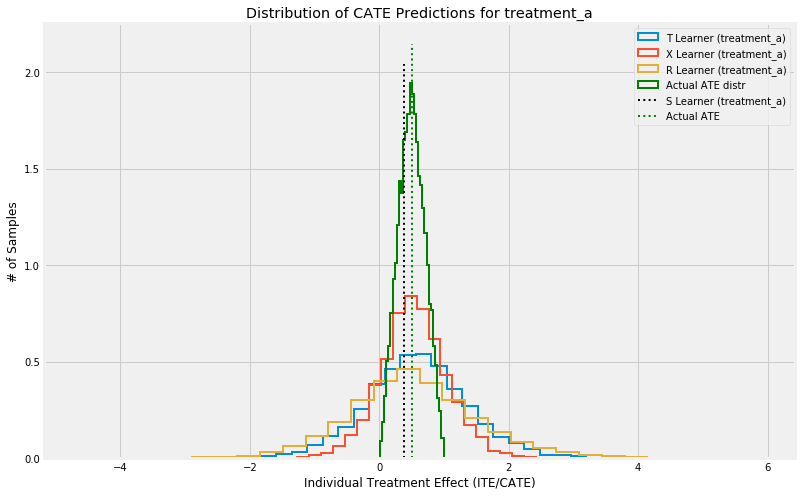

In [ ]:
groups = learner_r._classes

alpha = 1
linewidth = 2
bins = 30
for group,idx in sorted(groups.items(), key=lambda x: x[1]):
    plt.figure(figsize=(12,8))
    plt.hist(cate_t[:,idx], alpha=alpha, bins=bins, label='T Learner ({})'.format(group),
             histtype='step', linewidth=linewidth, density=True)
    plt.hist(cate_x[:,idx], alpha=alpha, bins=bins, label='X Learner ({})'.format(group),
             histtype='step', linewidth=linewidth, density=True)
    plt.hist(cate_r[:,idx], alpha=alpha, bins=bins, label='R Learner ({})'.format(group),
             histtype='step', linewidth=linewidth, density=True)
    plt.hist(tau, alpha=alpha, bins=bins, label='Actual ATE distr',
             histtype='step', linewidth=linewidth, color='green', density=True)
    plt.vlines(cate_s[0,idx], 0, plt.axes().get_ylim()[1], label='S Learner ({})'.format(group),
               linestyles='dotted', linewidth=linewidth)
    plt.vlines(tau.mean(), 0, plt.axes().get_ylim()[1], label='Actual ATE',
               linestyles='dotted', linewidth=linewidth, color='green')

    plt.title('Distribution of CATE Predictions for {}'.format(group))
    plt.xlabel('Individual Treatment Effect (ITE/CATE)')
    plt.ylabel('# of Samples')
    _=plt.legend()

---
## Multiple Treatment Case

### Generate synthetic data
Note: we randomize the assignment of treatment flag AFTER the synthetic data generation process, so it doesn't make sense to measure accuracy metrics here. Next steps would be to include multi-treatment in the DGP itself.

In [ ]:
# Generate synthetic data using mode 1
y, X, treatment, tau, b, e = synthetic_data(mode=1, n=10000, p=8, sigma=1.0)

treatment = np.array([('treatment_a' if np.random.random() > 0.2 else 'treatment_b')
                      if val==1 else 'control' for val in treatment])

e = {group: e for group in np.unique(treatment)}

In [ ]:
pd.Series(treatment).value_counts()

control        4768
treatment_a    4146
treatment_b    1086
dtype: int64

## S-Learner

### ATE

In [ ]:
learner_s = BaseSRegressor(XGBRegressor(), control_name='control')
ate_s = learner_s.estimate_ate(X=X, treatment=treatment, y=y, return_ci=False, bootstrap_ci=False)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.6339
INFO:causalml:    RMSE (Treatment):     0.6447
INFO:causalml:   sMAPE   (Control):     0.6148
INFO:causalml:   sMAPE (Treatment):     0.3498
INFO:causalml:    Gini   (Control):     0.8528
INFO:causalml:    Gini (Treatment):     0.8492
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.5584
INFO:causalml:    RMSE (Treatment):     0.4771
INFO:causalml:   sMAPE   (Control):     0.5699
INFO:causalml:   sMAPE (Treatment):     0.2768
INFO:causalml:    Gini   (Control):     0.8921
INFO:causalml:    Gini (Treatment):     0.9227


In [ ]:
ate_s

array([0.58349553, 0.58778215])

In [ ]:
learner_s._classes

{'treatment_a': 0, 'treatment_b': 1}

### ATE w/ Confidence Intervals

In [ ]:
alpha = 0.05
learner_s = BaseSRegressor(XGBRegressor(), ate_alpha=alpha, control_name='control')
ate_s, ate_s_lb, ate_s_ub = learner_s.estimate_ate(X=X, treatment=treatment, y=y, return_ci=True,
                                                   bootstrap_ci=False)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.6339
INFO:causalml:    RMSE (Treatment):     0.6447
INFO:causalml:   sMAPE   (Control):     0.6148
INFO:causalml:   sMAPE (Treatment):     0.3498
INFO:causalml:    Gini   (Control):     0.8528
INFO:causalml:    Gini (Treatment):     0.8492
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.5584
INFO:causalml:    RMSE (Treatment):     0.4771
INFO:causalml:   sMAPE   (Control):     0.5699
INFO:causalml:   sMAPE (Treatment):     0.2768
INFO:causalml:    Gini   (Control):     0.8921
INFO:causalml:    Gini (Treatment):     0.9227


In [ ]:
np.vstack((ate_s_lb, ate_s, ate_s_ub))

array([[0.5555693 , 0.55278018],
       [0.58349553, 0.58778215],
       [0.61142176, 0.62278413]])

### ATE w/ Boostrap Confidence Intervals

In [ ]:
ate_s_b, ate_s_lb_b, ate_s_ub_b = learner_s.estimate_ate(X=X, treatment=treatment, y=y, return_ci=True,
                                                         bootstrap_ci=True, n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.6339
INFO:causalml:    RMSE (Treatment):     0.6447
INFO:causalml:   sMAPE   (Control):     0.6148
INFO:causalml:   sMAPE (Treatment):     0.3498
INFO:causalml:    Gini   (Control):     0.8528
INFO:causalml:    Gini (Treatment):     0.8492
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.5584
INFO:causalml:    RMSE (Treatment):     0.4771
INFO:causalml:   sMAPE   (Control):     0.5699
INFO:causalml:   sMAPE (Treatment):     0.2768
INFO:causalml:    Gini   (Control):     0.8921
INFO:causalml:    Gini (Treatment):     0.9227
INFO:causalml:Bootstrap Confidence Intervals for ATE
100%|██████████| 100/100 [01:40<00:00,  1.00s/it]


In [ ]:
np.vstack((ate_s_lb_b, ate_s_b, ate_s_ub_b))

array([[0.52550035, 0.52550035],
       [0.58349553, 0.58778215],
       [0.64944596, 0.64944596]])

### CATE

In [ ]:
learner_s = BaseSRegressor(XGBRegressor(), control_name='control')
cate_s = learner_s.fit_predict(X=X, treatment=treatment, y=y, return_ci=False)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.6339
INFO:causalml:    RMSE (Treatment):     0.6447
INFO:causalml:   sMAPE   (Control):     0.6148
INFO:causalml:   sMAPE (Treatment):     0.3498
INFO:causalml:    Gini   (Control):     0.8528
INFO:causalml:    Gini (Treatment):     0.8492
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.5584
INFO:causalml:    RMSE (Treatment):     0.4771
INFO:causalml:   sMAPE   (Control):     0.5699
INFO:causalml:   sMAPE (Treatment):     0.2768
INFO:causalml:    Gini   (Control):     0.8921
INFO:causalml:    Gini (Treatment):     0.9227


In [ ]:
cate_s

array([[ 0.91381967,  0.82956386],
       [-0.17692167, -0.15709245],
       [ 0.90877771,  0.92332006],
       ...,
       [ 0.86159408,  0.53687155],
       [ 0.66541922,  0.78590739],
       [ 1.05691028,  1.03345728]])

### CATE w/ Confidence Intervals

In [ ]:
alpha = 0.05
learner_s = BaseSRegressor(XGBRegressor(), ate_alpha=alpha, control_name='control')
cate_s, cate_s_lb, cate_s_ub = learner_s.fit_predict(X=X, treatment=treatment, y=y, return_ci=True,
                               n_bootstraps=100, bootstrap_size=3000)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.6339
INFO:causalml:    RMSE (Treatment):     0.6447
INFO:causalml:   sMAPE   (Control):     0.6148
INFO:causalml:   sMAPE (Treatment):     0.3498
INFO:causalml:    Gini   (Control):     0.8528
INFO:causalml:    Gini (Treatment):     0.8492
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.5584
INFO:causalml:    RMSE (Treatment):     0.4771
INFO:causalml:   sMAPE   (Control):     0.5699
INFO:causalml:   sMAPE (Treatment):     0.2768
INFO:causalml:    Gini   (Control):     0.8921
INFO:causalml:    Gini (Treatment):     0.9227
INFO:causalml:Bootstrap Confidence Intervals
100%|██████████| 100/100 [01:03<00:00,  1.58it/s]


In [ ]:
cate_s

array([[ 0.91381967,  0.82956386],
       [-0.17692167, -0.15709245],
       [ 0.90877771,  0.92332006],
       ...,
       [ 0.86159408,  0.53687155],
       [ 0.66541922,  0.78590739],
       [ 1.05691028,  1.03345728]])

In [ ]:
cate_s_lb

array([[ 0.23816384, -0.32713253],
       [-0.44141183, -0.42676411],
       [-0.00206863, -0.43860602],
       ...,
       [ 0.29240462, -0.16563866],
       [-0.01797467, -0.10772878],
       [-0.51486325, -0.31691882]])

In [ ]:
cate_s_ub

array([[1.40557503, 1.1807412 ],
       [1.06860972, 1.55298753],
       [1.38529261, 1.6596471 ],
       ...,
       [1.56729684, 1.47052228],
       [1.16166003, 1.1144281 ],
       [1.68127107, 1.58984778]])

## T-Learner

### ATE w/ Confidence Intervals

In [ ]:
learner_t = BaseTRegressor(XGBRegressor(), control_name='control')
ate_t, ate_t_lb, ate_t_ub = learner_t.estimate_ate(X=X, treatment=treatment, y=y)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.4669
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.2675
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9297
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.0747
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.0568
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9984


In [ ]:
np.vstack((ate_t_lb, ate_t, ate_t_ub))

array([[0.53107041, 0.5296616 ],
       [0.55739303, 0.55794811],
       [0.58371565, 0.58623463]])

### ATE w/ Boostrap Confidence Intervals

In [ ]:
ate_t_b, ate_t_lb_b, ate_t_ub_b = learner_t.estimate_ate(X=X, treatment=treatment, y=y, bootstrap_ci=True,
                                                   n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.4669
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.2675
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9297
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.0747
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.0568
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9984
INFO:causalml:Bootstrap Confidence Intervals for ATE
100%|██████████| 100/100 [01:32<00:00,  1.08it/s]


In [ ]:
np.vstack((ate_t_lb_b, ate_t_b, ate_t_ub_b))

array([[0.51777538, 0.51777538],
       [0.55739303, 0.55794811],
       [0.67471492, 0.67471492]])

### CATE

In [ ]:
learner_t = BaseTRegressor(XGBRegressor(), control_name='control')
cate_t = learner_t.fit_predict(X=X, treatment=treatment, y=y)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.4669
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.2675
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9297
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.0747
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.0568
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9984


In [ ]:
cate_t

array([[ 1.47525787, -0.06651461],
       [ 1.26169336,  1.14718354],
       [ 1.68760026,  0.75878632],
       ...,
       [ 0.37292147,  0.20537615],
       [ 0.84290075,  0.80045319],
       [ 1.64227223,  1.91352534]])

### CATE w/ Confidence Intervals

In [ ]:
learner_t = BaseTRegressor(XGBRegressor(), control_name='control')
cate_t, cate_t_lb, cate_t_ub = learner_t.fit_predict(X=X, treatment=treatment, y=y, return_ci=True, n_bootstraps=100,
                                                    bootstrap_size=3000)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.4669
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.2675
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9297
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.0747
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.0568
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9984
INFO:causalml:Bootstrap Confidence Intervals
100%|██████████| 100/100 [01:06<00:00,  1.51it/s]


In [ ]:
cate_t

array([[ 1.47525787, -0.06651461],
       [ 1.26169336,  1.14718354],
       [ 1.68760026,  0.75878632],
       ...,
       [ 0.37292147,  0.20537615],
       [ 0.84290075,  0.80045319],
       [ 1.64227223,  1.91352534]])

In [ ]:
cate_t_lb

array([[-0.18706408, -0.84940575],
       [-1.01419897, -0.7311732 ],
       [-0.0427315 , -0.16378173],
       ...,
       [-0.39076423, -0.16869925],
       [-0.17401927, -0.19503389],
       [-0.61903974, -1.15808628]])

In [ ]:
cate_t_ub

array([[2.47563672, 1.69891493],
       [2.04089584, 1.76605188],
       [2.3567108 , 2.40833322],
       ...,
       [2.17926003, 2.26919731],
       [2.15714553, 1.91076722],
       [2.27031788, 2.03901908]])

## X-Learner

### ATE w/ Confidence Intervals

#### With Propensity Score Input

In [ ]:
learner_x = BaseXRegressor(XGBRegressor(), control_name='control')
ate_x, ate_x_lb, ate_x_ub = learner_x.estimate_ate(X=X, treatment=treatment, y=y, p=e)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.4669
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.2675
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9297
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.0747
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.0568
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9984


In [ ]:
np.vstack((ate_x_lb, ate_x, ate_x_ub))

array([[0.49573269, 0.54002602],
       [0.51860246, 0.56163457],
       [0.54147223, 0.58324311]])

#### Without Propensity Score Input

In [ ]:
ate_x_no_p, ate_x_lb_no_p, ate_x_ub_no_p = learner_x.estimate_ate(X=X, treatment=treatment, y=y)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.4669
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.2675
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9297
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.0747
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.0568
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9984


In [ ]:
np.vstack((ate_x_lb_no_p, ate_x_no_p, ate_x_ub_no_p))

array([[0.50418298, 0.56976992],
       [0.52706595, 0.59243233],
       [0.54994892, 0.61509475]])

### ATE w/ Boostrap Confidence Intervals

#### With Propensity Score Input

In [ ]:
ate_x_b, ate_x_lb_b, ate_x_ub_b = learner_x.estimate_ate(X=X, treatment=treatment, y=y, p=e, bootstrap_ci=True,
                                                   n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.4669
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.2675
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9297
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.0747
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.0568
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9984
INFO:causalml:Bootstrap Confidence Intervals for ATE
100%|██████████| 100/100 [02:55<00:00,  1.75s/it]


In [ ]:
np.vstack((ate_x_lb_b, ate_x_b, ate_x_ub_b))

array([[0.49600789, 0.49600789],
       [0.51860246, 0.56163457],
       [0.63696386, 0.63696386]])

#### Without Propensity Score Input

In [ ]:
ate_x_b_no_p, ate_x_lb_b_no_p, ate_x_ub_b_no_p = learner_x.estimate_ate(X=X, treatment=treatment, y=y, bootstrap_ci=True,
                                                   n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.4669
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.2675
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9297
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.0747
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.0568
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9984
INFO:causalml:Bootstrap Confidence Intervals for ATE
100%|██████████| 100/100 [02:54<00:00,  1.74s/it]


In [ ]:
np.vstack((ate_x_lb_b_no_p, ate_x_b_no_p, ate_x_ub_b_no_p))

array([[0.50100288, 0.50100288],
       [0.52706414, 0.59242806],
       [0.66020792, 0.66020792]])

### CATE

#### With Propensity Score Input

In [ ]:
learner_x = BaseXRegressor(XGBRegressor(), control_name='control')
cate_x = learner_x.fit_predict(X=X, treatment=treatment, y=y, p=e)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.4669
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.2675
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9297
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.0747
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.0568
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9984


In [ ]:
cate_x

array([[ 0.57149441,  0.10240081],
       [-0.43192272,  1.48913118],
       [ 1.13622262,  0.65923928],
       ...,
       [ 0.44651704, -0.23119723],
       [ 0.93875551,  0.77003003],
       [ 0.96697381,  0.99990004]])

#### Without Propensity Score Input

In [ ]:
cate_x_no_p = learner_x.fit_predict(X=X, treatment=treatment, y=y)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.4669
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.2675
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9297
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.0747
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.0568
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9984


In [ ]:
cate_x_no_p

array([[ 0.62959351, -0.00493521],
       [-0.48863166,  1.54109948],
       [ 1.17988308,  1.26200671],
       ...,
       [ 0.41320951,  0.73251634],
       [ 0.91104634,  0.82359481],
       [ 1.08867931,  1.44193089]])

### CATE w/ Confidence Intervals

#### With Propensity Score Input

In [ ]:
learner_x = BaseXRegressor(XGBRegressor(), control_name='control')
cate_x, cate_x_lb, cate_x_ub = learner_x.fit_predict(X=X, treatment=treatment, y=y, p=e, return_ci=True,
                                                     n_bootstraps=100, bootstrap_size=1000)

INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.4669
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.2675
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9297
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.0747
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.0568
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9984
INFO:causalml:Bootstrap Confidence Intervals
100%|██████████| 100/100 [00:51<00:00,  1.94it/s]


In [ ]:
learner_x._classes

{'treatment_a': 0, 'treatment_b': 1}

In [ ]:
cate_x

array([[ 0.57149441,  0.10240081],
       [-0.43192272,  1.48913118],
       [ 1.13622262,  0.65923928],
       ...,
       [ 0.44651704, -0.23119723],
       [ 0.93875551,  0.77003003],
       [ 0.96697381,  0.99990004]])

In [ ]:
cate_x_lb

array([[-0.23574115, -0.21029023],
       [-0.95699419, -1.05203708],
       [-0.49402807, -0.48280283],
       ...,
       [-0.12162789, -0.26408791],
       [-0.52562958, -0.19338615],
       [-0.40858565, -0.88119588]])

In [ ]:
cate_x_ub

array([[1.79950407, 2.11258332],
       [1.45309225, 1.48831446],
       [1.75564219, 2.03222137],
       ...,
       [2.15191078, 2.30032378],
       [1.65228261, 1.40411322],
       [1.74815254, 1.68257617]])

#### Without Propensity Score Input

In [ ]:
cate_x_no_p, cate_x_lb_no_p, cate_x_ub_no_p = learner_x.fit_predict(X=X, treatment=treatment, y=y, return_ci=True,
                                                     n_bootstraps=100, bootstrap_size=1000)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Error metrics for group treatment_a
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.4669
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.2675
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9297
INFO:causalml:Error metrics for group treatment_b
INFO:causalml:    RMSE   (Control):     0.4743
INFO:causalml:    RMSE (Treatment):     0.0747
INFO:causalml:   sMAPE   (Control):     0.5062
INFO:causalml:   sMAPE (Treatment):     0.0568
INFO:causalml:    Gini   (Control):     0.9280
INFO:causalml:    Gini (Treatment):     0.9984
INFO:causalml:Bootstrap Confidence Intervals
100%|██████████| 100/100 [00:51<00:00,  1.94it/s]


In [ ]:
learner_x._classes

{'treatment_a': 0, 'treatment_b': 1}

In [ ]:
cate_x_no_p

array([[ 0.6294132 , -0.00492528],
       [-0.48876998,  1.54111376],
       [ 1.17989094,  1.2620318 ],
       ...,
       [ 0.41319463,  0.73237091],
       [ 0.9108665 ,  0.82359564],
       [ 1.08868219,  1.441931  ]])

In [ ]:
cate_x_lb_no_p

array([[-0.10073893, -0.38800051],
       [-0.81971717, -0.8298923 ],
       [-0.18606629, -0.32586878],
       ...,
       [ 0.18372251, -0.12170252],
       [-0.21309623, -0.38600234],
       [-0.44863794, -0.39716903]])

In [ ]:
cate_x_ub_no_p

array([[2.00312255, 2.10486085],
       [1.59355675, 1.76340695],
       [1.77980204, 2.35535097],
       ...,
       [1.94828429, 1.94720835],
       [2.04021647, 1.71337955],
       [1.60121219, 1.82820234]])

## R-Learner

### ATE w/ Confidence Intervals

#### With Propensity Score Input

In [ ]:
learner_r = BaseRRegressor(XGBRegressor(), control_name='control')
ate_r, ate_r_lb, ate_r_ub = learner_r.estimate_ate(X=X, treatment=treatment, y=y, p=e)

INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss
INFO:causalml:training the treatment effect model for treatment_b with R-loss


In [ ]:
np.vstack((ate_r_lb, ate_r, ate_r_ub))

array([[0.52326968, 0.57744164],
       [0.52374892, 0.5781462 ],
       [0.52422816, 0.57885076]])

#### Without Propensity Score Input

In [ ]:
learner_r = BaseRRegressor(XGBRegressor(), control_name='control')
ate_r_no_p, ate_r_lb_no_p, ate_r_ub_no_p = learner_r.estimate_ate(X=X, treatment=treatment, y=y)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Calibrating propensity scores.
INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss
INFO:causalml:training the treatment effect model for treatment_b with R-loss


In [ ]:
np.vstack((ate_r_lb_no_p, ate_r_no_p, ate_r_ub_no_p))

array([[0.44161159, 0.71836119],
       [0.44209269, 0.71904979],
       [0.44257378, 0.71973838]])

In [ ]:
learner_r.propensity_model

{'treatment_a': {'all training': LogisticRegressionCV(Cs=array([1.00230524, 2.15608891, 4.63802765, 9.97700064]),
                       class_weight=None,
                       cv=KFold(n_splits=5, random_state=None, shuffle=True),
                       dual=False, fit_intercept=True, intercept_scaling=1.0,
                       l1_ratios=array([0.001     , 0.33366667, 0.66633333, 0.999     ]),
                       max_iter=100, multi_class='auto', n_jobs=None,
                       penalty='elasticnet', random_state=None, refit=True,
                       scoring=None, solver='saga', tol=0.0001, verbose=0)},
 'treatment_b': {'all training': LogisticRegressionCV(Cs=array([1.00230524, 2.15608891, 4.63802765, 9.97700064]),
                       class_weight=None,
                       cv=KFold(n_splits=5, random_state=None, shuffle=True),
                       dual=False, fit_intercept=True, intercept_scaling=1.0,
                       l1_ratios=array([0.001     , 0.33366667,

### ATE w/ Boostrap Confidence Intervals

#### With Propensity Score Input

In [ ]:
ate_r_b, ate_r_lb_b, ate_r_ub_b = learner_r.estimate_ate(X=X, treatment=treatment, y=y, p=e, bootstrap_ci=True,
                                                   n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss
INFO:causalml:training the treatment effect model for treatment_b with R-loss
INFO:causalml:Bootstrap Confidence Intervals for ATE
100%|██████████| 100/100 [02:19<00:00,  1.39s/it]


In [ ]:
np.vstack((ate_r_lb_b, ate_r_b, ate_r_ub_b))

array([[0.40326436, 0.40326436],
       [0.50620059, 0.5478152 ],
       [0.5697328 , 0.5697328 ]])

#### Without Propensity Score Input

In [ ]:
learner_r = BaseRRegressor(XGBRegressor(), control_name='control')
ate_r_b_no_p, ate_r_lb_b_no_p, ate_r_ub_b_no_p = learner_r.estimate_ate(X=X, treatment=treatment, y=y, bootstrap_ci=True,
                                                   n_bootstraps=100, bootstrap_size=5000)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Calibrating propensity scores.
INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss
INFO:causalml:training the treatment effect model for treatment_b with R-loss
INFO:causalml:Bootstrap Confidence Intervals for ATE
100%|██████████| 100/100 [02:19<00:00,  1.39s/it]


In [ ]:
np.vstack((ate_r_lb_b_no_p, ate_r_b_no_p, ate_r_ub_b_no_p))

array([[0.45994051, 0.45994051],
       [0.44481491, 0.66323246],
       [0.68981572, 0.68981572]])

### CATE

#### With Propensity Score Input

In [ ]:
learner_r = BaseRRegressor(XGBRegressor(), control_name='control')
cate_r = learner_r.fit_predict(X=X, treatment=treatment, y=y, p=e)

INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss
INFO:causalml:training the treatment effect model for treatment_b with R-loss


In [ ]:
cate_r

array([[ 5.57098567e-01,  1.77359581e-03],
       [ 1.08587885e+00,  2.48472750e-01],
       [ 3.34437251e-01,  1.69020355e+00],
       ...,
       [-9.96065974e-01, -8.98482800e-02],
       [ 1.70625651e+00,  9.55640435e-01],
       [-1.88456130e+00,  6.50659442e-01]])

#### Without Propensity Score Input

In [ ]:
learner_r = BaseRRegressor(XGBRegressor(), control_name='control')
cate_r_no_p = learner_r.fit_predict(X=X, treatment=treatment, y=y)

INFO:causalml:Generating propensity score
INFO:causalml:Calibrating propensity scores.
INFO:causalml:Calibrating propensity scores.
INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss
INFO:causalml:training the treatment effect model for treatment_b with R-loss


In [ ]:
cate_r_no_p

array([[ 0.55478877,  0.87992519],
       [ 1.10120189,  1.29564619],
       [ 0.62448621,  0.41555083],
       ...,
       [-0.53886592,  0.44593787],
       [ 1.25231111,  0.79904991],
       [-0.64419305, -0.23014426]])

### CATE w/ Confidence Intervals

#### With Propensity Score Input

In [ ]:
learner_r = BaseRRegressor(XGBRegressor(), control_name='control')
cate_r, cate_r_lb, cate_r_ub = learner_r.fit_predict(X=X, treatment=treatment, y=y, p=e, return_ci=True,
                                                     n_bootstraps=100, bootstrap_size=1000)

INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss
INFO:causalml:training the treatment effect model for treatment_b with R-loss
INFO:causalml:Bootstrap Confidence Intervals
100%|██████████| 100/100 [00:37<00:00,  2.65it/s]


In [ ]:
cate_r

array([[ 1.75007784,  0.67752302],
       [ 0.77257723,  0.12910607],
       [ 1.08854032,  0.81679094],
       ...,
       [-0.92310214,  0.645491  ],
       [ 0.92478108,  0.79903334],
       [-0.48311949,  1.00291944]])

In [ ]:
cate_r_lb

array([[-0.801657  , -0.48754777],
       [-3.05317249, -5.37572038],
       [-1.50823961, -1.16822439],
       ...,
       [-1.27909884, -1.2460175 ],
       [-1.42656819, -1.59059022],
       [-1.90115855, -2.10247456]])

In [ ]:
cate_r_ub

array([[4.06750882, 3.68516954],
       [4.21587243, 4.50271177],
       [4.33370841, 3.79358828],
       ...,
       [3.53610538, 3.48638564],
       [3.71832166, 3.48292163],
       [5.01262635, 3.27047309]])

#### Without Propensity Score Input

In [ ]:
learner_r = BaseRRegressor(XGBRegressor(), control_name='control')
cate_r_no_p, cate_r_lb_no_p, cate_r_ub_no_p = learner_r.fit_predict(X=X, treatment=treatment, y=y, p=e, return_ci=True,
                                                     n_bootstraps=100, bootstrap_size=1000)

INFO:causalml:generating out-of-fold CV outcome estimates
INFO:causalml:training the treatment effect model for treatment_a with R-loss
INFO:causalml:training the treatment effect model for treatment_b with R-loss
INFO:causalml:Bootstrap Confidence Intervals
  2%|▏         | 2/100 [00:00<00:36,  2.69it/s]

In [ ]:
cate_r_no_p

In [ ]:
cate_r_lb_no_p

In [ ]:
cate_r_ub_no_p